# How to Choose One Card By Analyzing Every Draft Ever

## Introduction

Welcome to my new platform dedicated to limited analytics! Over the coming weeks I'll be adding both technical content aimed at those with an interest in math or quantitative development as it applies to limited play, as well as more expository content when I think my results are relevant to the average draft enthusiast. This article falls under the latter category.

I've got some exciting stuff to show you, so I'll cut the preamble short. We're going to take a serious look at answering the question "How should I draft" using techniques that have not been attempted before, and with a wider scope than any similar analysis.

Ok, sorry, let me try again: we're going to look at answering the question "How should I pick my first card", and we're going deep. The rest of the draft is up to you, but pack one, pick one, that's a pick order. We rank the cards and pick the one that's highest in our list. We don't *have* to do that, but it works well enough. Recent years have seen the rise of GIH WR as the default objective reference for card rankings, but I don't think anyone has attempted to seriously answer the question "what happens when I take the highest GIH WR card from pack one and go from there," or to deeply compare the effects of relying on different metrics to make card choices. We're going to do that now, and more.

The way we're going to do that is conceptually simple and computationally somewhat complex. The simplest (relevant) thing to do is to just, well, look at when people took the highest GIH WR card and see what happened. For example, Sierko took at a look at player behavior around the GP WR metric in Foundations recently, including the question of what happens when people pick the highest ranked card and what happens when they don't. They do better when they do. The problem with drawing conclusions from that analysis is that, like in poker, the most valuable decisions we make are often the easiest. No one is having trouble slamming Sire of Seven Deaths P1P1, so those results, along with every other clear bomb, are going to fall into the "yes, you took the good card" bucket and skew the results. Given the major impact on the very best bombs on win rate, I think we should handle variation in opening luck carefully before drawing conclusions.

We could look at trying to adjust for opening luck using some kind of factor, but that's confounded by exactly the thing were trying to measure, so here's my solution: we need to know what happens when we take the highest ranked card from *every* pack using actual match results, not just the ones that were observed to be taken. For every draft, we'll identify the highest ranked card according to some metric, then go find a draft where that card was taken first, and swap out the results. Actually, we'll take all of the representative drafts and average the results. And while we're at it, we'll look at all the sets instead of just one. And all the metrics instead of just one. There will be more technical details to discuss later, but this is the essence of the analysis.

Now, when we make this swap, we want the results to be as representative as possible to results that would have been obtained in the counterfactual. That is, ideally, the same player, on the same day. We might even ask for the card picked to be itself highest ranked, to simulate the concept of the strategy and not just the card picked, or for the distribution of alternatives to be similar, if we're feeling really greedy. Obviously we can't get that using real data, but I'll address each of these points briefly before we get to the results.

First, the player. Player skill is obviously an important driver of results beyond pick one, so it will be necessary to control for the variable. Otherwise we could just be observing more informed players making characteristic choices and winning due to their skill, rather than the effect of the choice itself. [17Lands](https://www.17lands.com/public_datasets) provides us with two invaluable but coarse data points pertaining to player skill, in the form of a "WR Bucket" data point, with intervals of 2%, measuring the players win rate over the set in question, and an "N Games" data point, counting the games played by that player. I used Bayesian inference to combine those two values to produce an estimate of player skill by regressing the win rate bucket variable back to the mean of 54% according to the number of games played. Then I truncated the results at 42% and 66% and combined the extreme outliers into those buckets. For details on the exact methodology see [this post](bayes-cohorts). I call the resulting value the "Skill Cohort"

So suppose your favorite streamer is an elite drafter who regularly posts a 64% win rate and plays over 500 games per set. Probably they will end up in the 62% bucket for each set. Only absolute maniacs are getting assigned to the 66% bucket, but there is generally one or two to be found per set. There are interesting things to look at even for this small sample size, but we shouldn't necessarily consider the results on the analysis conclusive out on the fringes. We'll take a close look at sample sizes later. In any case, I would consider anything north of 60 "elite". Now, I think having a representative player make the substitute choice is essential to the analysis, so rather than just making an adjustment for skill, I will attempt to enforce that a substitute draft is found within the same cohort as the opened pack. Depending on sample size and the weirdness of the suggestion (something we will measure and look at below), there may not be an example within the same skill cohort, in which case we go looking in neighboring cohorts, and this time we do attempt to adjust for skill (by adjusting the observed win rate appropriately). If nobody can be found making the pick in question within three neighboring cohorts, we assume the pick is providing no value, and use the cohorts baseline win rate adjusted downward by the estimated value of a first pick, for which I used 2.5%. All this adjusting is necessary to get something usable at every point on the curve, but the most significant results are derived purely from the one-for-one substitution within the player cohort, or with de minimus adjustments on the boundaries.

The other elements of proximity I mentioned I did not adjust for in the final analysis, but I did look at them. In general, the most effective metrics pushed the average date of the observed draft later in the data set, when more people were making better evaluations. I don't think it's probable that the results obtained from that are somehow exploiting the metagame in a way that would invalidate then, if we're seeking to explain away a modeled increase in win rate. If anything, I think that kind of result is probably attenuated from what would have been realized by being ahead of the curve. Next, the idea of replacing drafts only with drafts where the card in question was picked *as* the highest-ranked card in the pack was my original strategy. It added noise to the result, tripled the compute time, and seemed to offer nothing of value empirically, so I cleaned it up. Finally, there is a more technical approach to doing this kind of thing by assigning a weight variable to each relevant draft that is some exponentially decaying function of the player, date, and a component analysis of the pack contents, and using a weighted average to obtain our result. I think this could give smoother results, but it has a cost in grokkability. I might try it down the road.

Let's get to the results. The metrics I looked at were GIH WR, GP WR, ATA, and IWD. I took a brief look at OH WR as well, but the picks were really poorly represented by player behavior, so I don't think there's anything to see there. 

...

Ok, I'm not fooling anyone, I threw [DEq](https://docs.google.com/spreadsheets/d/1n1pfrb5q_2ICYk-vfF3Uwo8t61DJU-5T_DFe0dwk8DY/edit?usp=sharing) in the mix as well -- obviously, proving that my pet metric is the best is the whole point of this exercise. If you want to dive into the reasoning behind DEq, I wrote up a [derivation of the formula](deq) just for you. Really, literally, just for you, the one person who wants to wade through a needless pile of conditional probabilities.

## Results of the Substitution Analysis

I took five metrics, and public data for 16 major releases going back to NEO covering almost 2.27 million drafts. So no, not every draft ever, just the ones with a large enough collection of drafts and the necessary data points (particularly the skill cohort fields, which are missing from data before NEO). I divided each format into an "early" stage, covering prerelease and the first 12 days proper, and a "late" stage, chosen to split the corpus roughly in half. For the first cut, I calculated the metrics using the late format and an in-sample analogue of "Top" players, then applied the results to the entire set of drafts, set-by-set and metric-by-metric. One point I haven't mentioned is the event length weighting. Since the number of games you play is a function of win rate, for each pick pointed out by the metric, I weight the result by the number of drafts where that pick is pointed out times the average event length of events measured in the substitution set. Therefore, each metric has a slightly different total weight for each set, which we expect to closely track the real number of matches observed. This value also serves as an effective sanity check on the substitution procedure, so I'll show what that looks like. For each set, for each cohort, I documented the win rate resulting from the procedure described above, and plot the delta between the simulated metric strategy and the actual observed win rate by cohort. Time to present the results. I'm presenting this as an executable notebook. If you want to try this yourself, you'll need to clone and install my deq repository and the "spells-mtg" python package and be prepared to put your CPU in the oven for several hours.

In [28]:
# Imports and some definitions you might want to look at but probably don't

# Uncomment and run to download every public data set used in the analysis and set up spells.

# See (https://github.com/oelarnes/spells) for the function of the below line, which will download files to your computer
# !spells add all
from great_tables import GT
import polars as pl
from spells import summon, ColName

from deq.plot import p1strat_line_plot, metric_weight_bar_plot, cohort_summary_table
from deq.p1_strategy import all_metrics_analysis, SETS
import matplotlib.pyplot as plt
pl.Config.set_tbl_rows(1000)

TOP_FILTER = {ColName.PLAYER_COHORT: 'Top'}
LATE_FORMAT = {'lhs': ColName.FORMAT_DAY, 'op': '>=', 'rhs': 13}
EARLY_FORMAT = {'$not': LATE_FORMAT}
LATE_TOP = {'$and': [TOP_FILTER, LATE_FORMAT]}
EARLY_TOP = {'$and': [TOP_FILTER, EARLY_FORMAT]}

print(f"Analyzed sets: {SETS}")
print(f"""Total number of drafts observed: {summon(
    SETS,
    columns=[ColName.NUM_DRAFTS], 
    group_by=[]
)['num_drafts'][0]}""")

Analyzed sets: ['MOM', 'MH3', 'DSK', 'LTR', 'OTJ', 'DMU', 'FDN', 'KTK', 'BRO', 'WOE', 'SNC', 'BLB', 'ONE', 'LCI', 'NEO', 'MKM']
Total number of drafts observed: 2269905


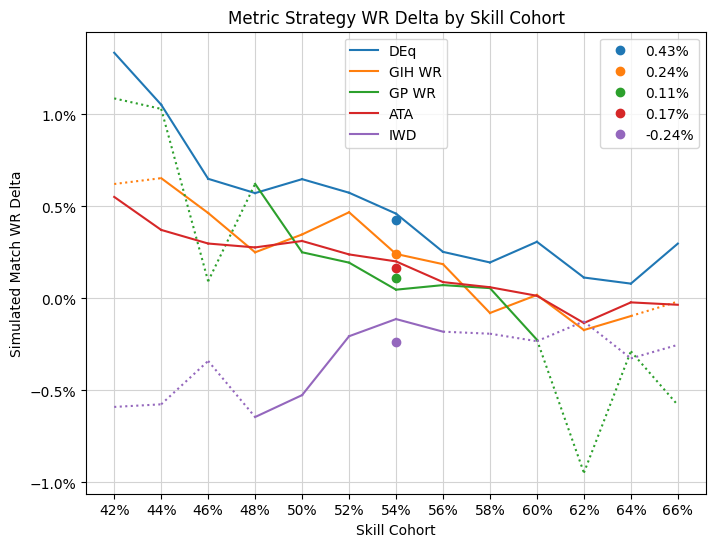

In [22]:
res_all = all_metrics_analysis(
    metric_filter=LATE_TOP
)
_ = p1strat_line_plot(res_all, mode='wr_delta')
plt.show()

## Interpreting the Results

The dots aligned above the 54% cohort represent the average increase in winrate aggregated across all of the cohorts. By picking the highest card in each pack one, as ranked by DEq (as calculated over the late format, top player metagame), in each draft, over 2.27 million drafts, the model estimates a 0.43% increase in win rate. Keep in mind, this is the result of *one* single choice made differently. In practice, you get to think about DEq for as many picks as you want to, and you get to (actually are compelled to by the laws of thermodynamics, we'll get to that) use a version more closely aligned to the present metagame. I think it's reasonable to guess that there are a few full percentage points of win rate at play here for a huge majority of players, just by taking card quality estimation seriously. Not only that, but the result, *independently*, applies to each of the cohorts at least up to the 62% cohort, well into what we considered elite players. Furthermore, it is the only metric to deliver clearly net positive results for any of the 58% and above cohorts.

Let me briefly talk about the dotted lines. I mentioned that I was keeping track of how far afield we have to look across neighboring cohorts to find a substitute draft. I track a "misrepresentation index" from 0 (found within cohort) to 4 (not found in any nearby cohort), and aggregate that index for each metric and cohort. Let me present the graph of that metric, which explains the dotted lines.

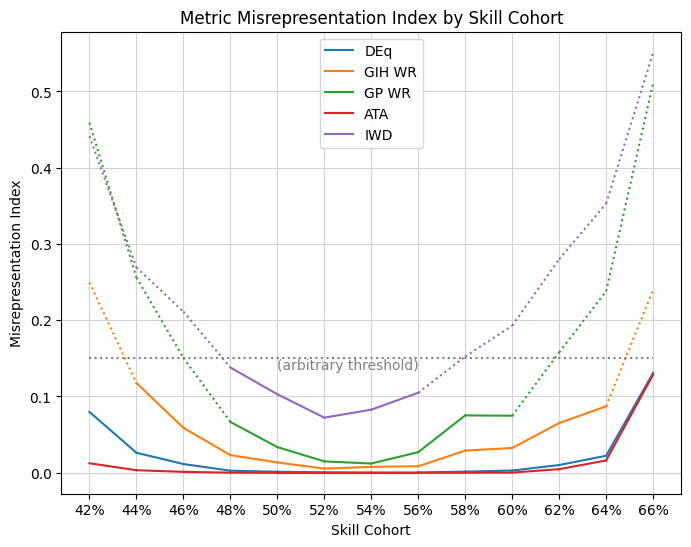

In [23]:
_ = p1strat_line_plot(
    res_all,
    mode='misrep'
)
plt.show()

Recalling that the misrepresentation index for a single pick ranges from 0 to 4, a mean value of 0.1 means that, looking at the picks suggested by that particular metric for that particular cohort, either 10% of those picks were not chosen P1P1 by anyone in the cohort for any draft within the sample, but were found in a neighboring cohort, or 2.5% of the picks suggested were not picked by *anyone* with proximity in skill, or, more likely, some combination of those outcomes. Obviously that's not terribly scientific, but the overall picture is clear. Some metrics are suggesting picks that are much more in line with player behavior than others. Specifically, DEq and ATA are suggesting highly representative picks, to the point that the misrepresentation for cohorts between 48% and 60% is de minimus, if not zero. The uptick at the boundaries is entirely a consequence of sample size. Some mythics wouldn't even be opened more than once by players in the 66% cohort, so if they were passed up in one single draft, that would count towards misrepresentation. Of course we could look at the exact numbers but I think the chart gives sufficient sense of scale. After DEq and ATA, GIH WR, GP WR, and IWD are successively worse at giving representative picks. My opinion is that both charts should be taken as evidence of metric quality. The fact that ATA points to elite behavior far more effectively than GIH WR should be taken seriously.

As for the dotted lines, the interpretation should be clear from the graph. I picked some threshold, 0.15, that gave a good indication of the outlying cases of misrepresentation, and present the connecting line as dotted with either endpoint exceeds that threshold. So the values in the win-rate plot connected by solid lines are the ones that are perhaps more reliable than the others.

Combining the results of the two analyses, from this sample at least, I think DEq comes out as a clear winner. We get the best of both worlds, a metric that replicates human behavior as well as the actual measurement of human behavior, and delivers the best results. There's no cohort of players that clearly wouldn't benefit (as opposed to "wouldn't clearly") from using DEq to guide first picks. Let's briefly touch on the other metrics. GIH WR comes in second in the win-rate analysis, which shouldn't surprise most of you that rely on it as a card quality metric. Frankly, I was expecting ATA to be second, because I've overrated the flaws of GIH WR and underrated how the in-game win rate signal can give durable card quality information. But GP WR and ATA also appear to be useful signals, especially for top players where GIH WR is less apparently useful. Note that many of those players will already be using GIH WR to inform their choices, but not so much that the strategy has great representation in the substitution analysis. Finally IWD is just... no. Do not use IWD as a card-quality metric. It does have information content, but do not argue that one card is better than another because it has higher IWD. Just no. 

Let's take a quick look at the sample sizes and cohort win rates underlying the data just to get the appropriate context. This chart will show the total "weight", that is, the estimated number of matches, under the actual sample and then the simulated strategies. We really expect the simulated strategies to look very similar to the actual sample, but not identical. Making better picks will lead to playing more matches.

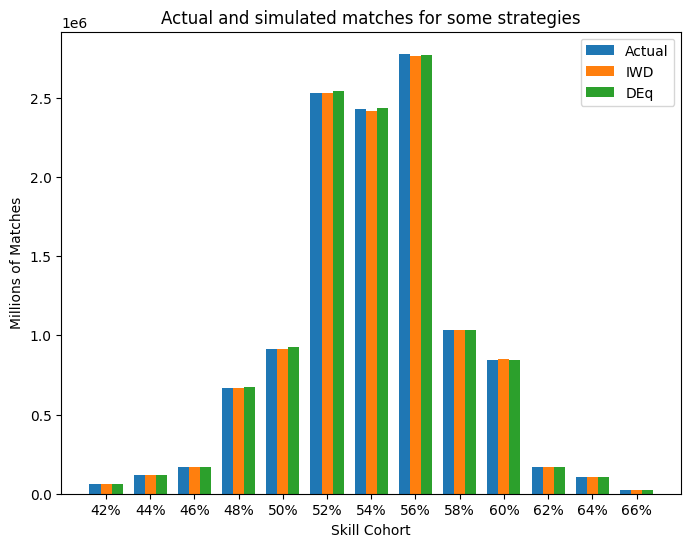

Skill Cohort,Match Win Rate,Num Matches
42%,39.1%,59170
44%,40.7%,116324
46%,43.0%,168587
48%,45.6%,670394
50%,46.9%,916369
52%,50.6%,2530358
54%,54.5%,2425343
56%,59.1%,2777196
58%,62.5%,1034853
60%,63.7%,843856


In [29]:
_ = metric_weight_bar_plot(res_all, metrics=['iwd', 'deq'])
plt.show()
cohort_summary_table(res_all)

Simulated weights look good, so let's take a look at the win rate table. Note the extreme win rates for the higher skill cohorts. Recall that this is expected and is due to our prior belief that a given player has average skill until we observe a large number of matches. The average player estimated to have skill 60% has a 63.7% win rate in the sample. We should be aware of a strong luck effect within the higher cohorts, but I'm not sure how it affects our results. Finally, those sample sizes for the last three cohorts are not large at all. Even the 62% bucket should be considered the best of the best. Those 22,000 matches for the 66% cohort are spread across all 16 formats, so just a couple hundred drafts per set on average. Nevertheless, you can still learn from a few hundred or few thousand drafts, so I don't mind presenting the results. Importantly, it also segregates those results from the estimates for the intermediate cohorts. 

The last thing I'll point out about the results so far is the slightly strange shape of the weight plot. Note that the 52% and 56% cohorts are larger than one would expect from a normal distribution. This effect is an artifact of the coarse bucketing of the "N Games" values and the particular constants I chose for the Bayesian skill estimation. Both the "56%/100" and "58%/100" buckets get lumped into the 56% skill cohort, and these are two of the largest cohorts in the original datasets. I'm not too concerned about how this affects the results, but it's worth understanding.

## Reproducible Strategies

Now, there's a major hole in this scheme. You can't make picks based on what metrics look like at the end of the format; you have to work with what you've got at the time. I felt it was important to start with the broadest analysis possible to get an idea of the stability of the analysis, and also I think there's value in a backward-looking evaluation of card quality. I picked the metrics the way I would suggest evaluating them for that purpose, so I think this suggests that DEq is the best way to look at which cards were most valuable early picks over the entire format.

Nevertheless we need to look at reproducible strategies, that is, something you could actually implement in practice. We have two passes through the data. First, the filter used we calculate the metrics, and second, the set of drafts that we compare using the substitution analysis. The second set must necessarily be as large as is practical, because we saw representation issues even when using the full data set, but the first filter can represent whatever we would use in practice. So let's start with the day one metrics. That first rush we get when the 17Lands card data page fills up with numbers on that first Wednesday morning. We will use those rankings, and take the first 12 days of the format as our substitution set. Here are the results of that analysis:

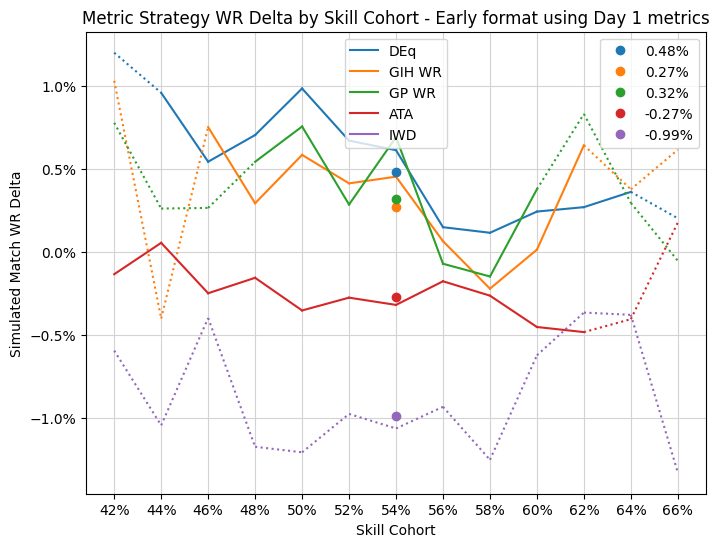

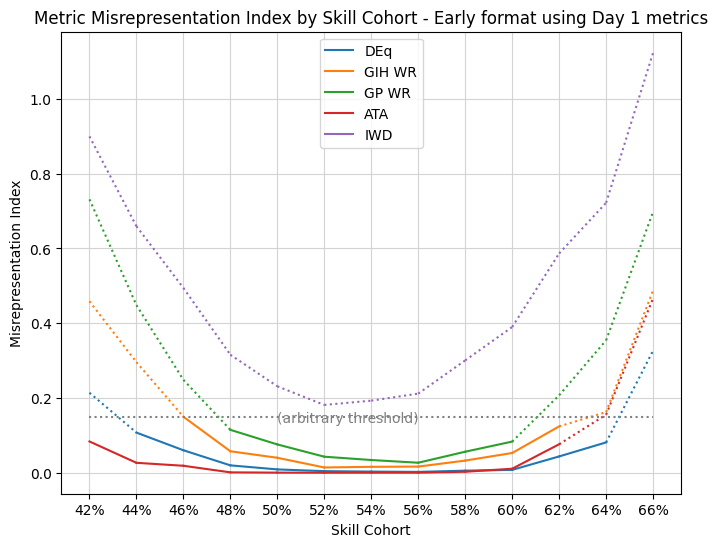

In [30]:
res_d1 = all_metrics_analysis(
    metric_filter={'format_day': 1},
 
    results_filter=EARLY_FORMAT
)
tag_d1 = "Early format using Day 1 metrics"
_ = p1strat_line_plot(
    res_d1, 
    mode='wr_delta',
    title_extra=tag_d1
)
plt.show()
_ = p1strat_line_plot(
    res_d1,
    mode='misrep',
    title_extra=tag_d1
)
plt.show()

To me, this was the most surprising and gratifying result of the bunch. Again, DEq comes out on top, although perhaps less conclusively, providing 0.48% of win rate on average across the entire data set (this time, just over a million drafts). This is from changing a single pick, and from continuing to use the day one cut for 12 days of the format! The thing that really shocked me was the gap between DEq and ATA. DEq is effectively a combination of ATA and GP WR, so for ATA to perform so poorly but this not to affect the quality of the result was pretty exciting for me. I honestly had no clue how ATA or the win rate metrics would perform, so it was exciting to see a result as clear as this. The results make sense intuitively as well (though that didn't make them predictable, for me anyway). The metric is drawn from the whole player base on day 1, and ATA measures the player base's knowledge of the format -- which is nil, in this case. So it's intuitive that relying on that knowledge to make picks is a bad idea, but it's still amazing to see the stark difference between this result and the previous one where relying on ATA was comparable to GIH WR in quality.

Additionally, we see GP WR outperform GIH WR. While I didn't predict it, it's another intuitive result since early days of the format are all about identifying the most powerful decks and exploiting them. GP WR is the stat that will help you do that (aside from DEq, of course). We see an interesting spike for GP WR and GIH WR around 60%-62%, which could be notable, but overall we can tell the halved sample size is already taking its toll on the quality of the analysis, especially when we take a look at the misrepresentation index. GP WR might be pointing us towards exploitable decks, but it also seems to be recommending plenty of unpalatable choices, to the eyes of our human drafters anyway. DEq again gives the most solid representative picks, especially for the elite cohorts.

Overall, I think this is a clear call to value those early day's returns highly. For this data set, anyway, there is apparently a lot of juice to squeeze for more wins.

Next up, we'll evaluate the late format using metrics from the early format. This transition period to the stable metagame can be especially difficult for those of us relying on metrics, which can still be pointing to archetypes which have had the life squeezed out of them. Let's take a look:

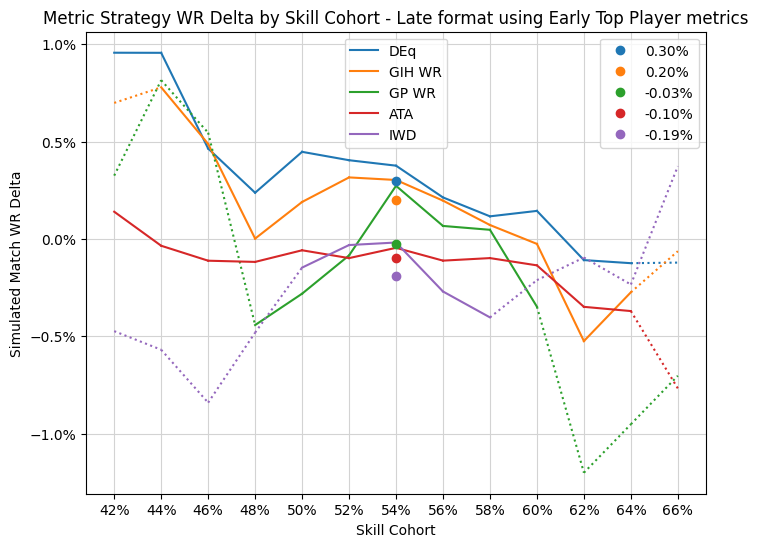

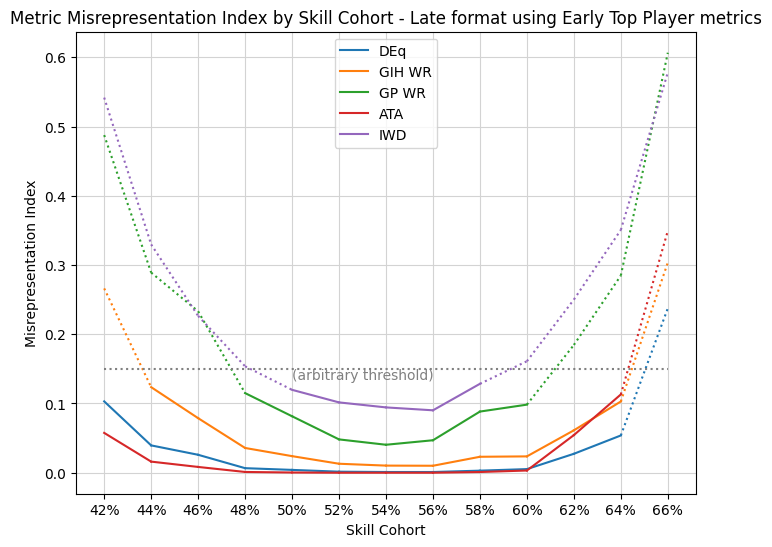

In [32]:
tag_luet = 'Late format using Early Top Player metrics'
res_luet = all_metrics_analysis(
    metric_filter=EARLY_TOP,
    results_filter=LATE_FORMAT
)
_ = p1strat_line_plot(
    res_luet, 
    mode='wr_delta',
    title_extra=tag_luet
)
plt.show()
_ = p1strat_line_plot(
    res_luet,
    mode='misrep',
    title_extra=tag_luet
)
plt.show()

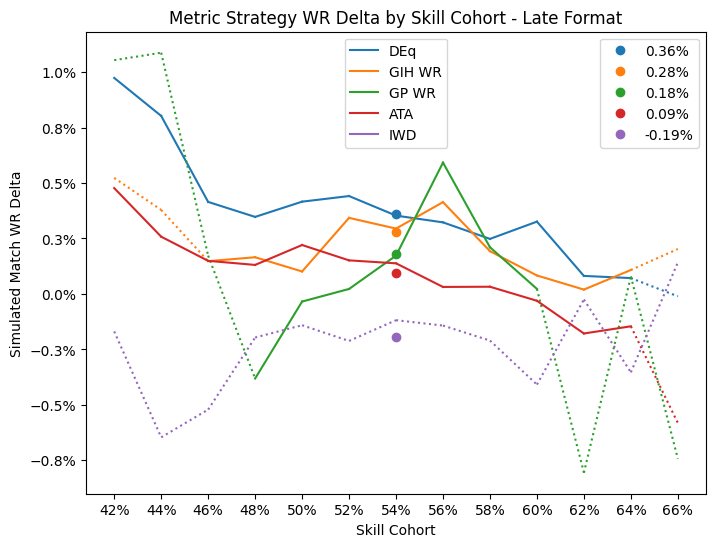

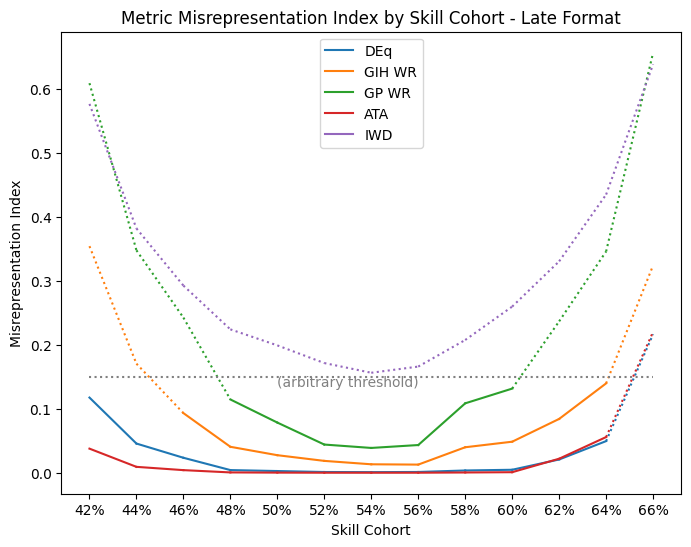

In [37]:
tag_late = 'Late Format'
res_late = all_metrics_analysis(
    metric_filter=LATE_TOP,
    results_filter=LATE_FORMAT
)
_ = p1strat_line_plot(
    res_late, 
    mode='wr_delta',
    title_extra=tag_late
)
plt.show()
_ = p1strat_line_plot(
    res_late,
    mode='misrep',
    title_extra=tag_late
)
plt.show()